# First steps processing delay data from NGL

Download the data from: https://geodesy.unr.edu/NGLStationPages/stations/KUGE.sta from the column: Tot./Wet Zenith Delay, etc.

Download the years 2026, 2025, 2024 (zip files). These will need to be unzipped into separate directories (call them by the year). You can do that via the command line with:
```bash
mkdir 2024
cd 2024
unzip ../KUGE.2024.trop.zip
```
Now, each date has a separate file. You can view the file (for example, KUGE.2024.333.trop.gz).

The first three lines of data look like:
```bash
*SITE ___EPOCH____ TROTOT _SIG TRWET TGETOT _SIG TGNTOT _SIG WVAPOR _SIG MTEMP
 KUGE 24:333:00000 2011.0  4.6  25.7   1.02 0.69   2.73 0.61   3.95 0.71 268.6
 KUGE 24:333:00300 2010.8  4.3  25.5   1.03 0.66   2.72 0.58   3.90 0.66 268.6
 KUGE 24:333:00600 2010.9  4.1  25.5   1.04 0.64   2.70 0.57   3.90 0.63 268.7
```
The second colum describe the time in epoch (year 2024, day 333 and then the decimal fraction of the day). The sampling interval is 300 s (5 minutes). The next columns give:
Total Wet Zenith Tropo Delay and uncertainty,
Total Wet Zenith Tropo Delay
East Gradient and uncertainty,
North Gradient and uncertainty,
Water Vapor and uncertainty, 
Mean Temp

We are only interested in the column WVAPOR. The units for the Integrated Water Vapour (IWV) / Precipitable Water Vapour (PWV) are Kilograms per square meter (kg/m^2) or interchangeably Millimeters (mm). 
These two units are equivalent. 

You can also read directly from the compressed files using `pandas`.



In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# we test with one filename first:
# we skip the first 54 rows and the last two, because they describe the file
fname='2024/KUGE.2024.333.trop.gz'
pd.read_csv(fname, skiprows=54, delimiter=r'\s+', skipfooter=2, engine='python')

,*SITE,___EPOCH____,TROTOT,_SIG,TRWET,TGETOT,_SIG.1,TGNTOT,_SIG.2,WVAPOR,_SIG.3,MTEMP
0,KUGE,24:333:00000,2011.0,4.6,25.7,1.02,0.69,2.73,0.61,3.95,0.71,268.6
1,KUGE,24:333:00300,2010.8,4.3,25.5,1.03,0.66,2.72,0.58,3.90,0.66,268.6
2,KUGE,24:333:00600,2010.9,4.1,25.5,1.04,0.64,2.70,0.57,3.90,0.63,268.7
3,KUGE,24:333:00900,2011.3,4.0,25.8,1.03,0.62,2.66,0.56,3.96,0.61,268.7
4,KUGE,24:333:01200,2011.5,3.8,26.1,1.02,0.60,2.65,0.55,3.99,0.59,268.7
...,...,...,...,...,...,...,...,...,...,...,...,...
283,KUGE,24:333:84900,2028.7,4.7,35.9,0.73,0.73,1.27,0.66,5.49,0.72,267.7
284,KUGE,24:333:85200,2028.7,5.0,36.0,0.72,0.74,1.28,0.68,5.49,0.76,267.6
285,KUGE,24:333:85500,2028.6,5.2,35.8,0.72,0.76,1.28,0.70,5.47,0.79,267.6
286,KUGE,24:333:85800,2028.4,5.4,35.7,0.72,0.78,1.28,0.72,5.45,0.83,267.6


In [3]:
# we use white space delineation and only read in column 0, 1, 9
pd.read_csv(fname, skiprows=54, delimiter=r'\s+', skipfooter=2, usecols=[0,1,9], engine='python')

,*SITE,___EPOCH____,WVAPOR
0,KUGE,24:333:00000,3.95
1,KUGE,24:333:00300,3.90
2,KUGE,24:333:00600,3.90
3,KUGE,24:333:00900,3.96
4,KUGE,24:333:01200,3.99
...,...,...,...
283,KUGE,24:333:84900,5.49
284,KUGE,24:333:85200,5.49
285,KUGE,24:333:85500,5.47
286,KUGE,24:333:85800,5.45


In [4]:
# we store this in a pandas dataframe
kuge_2024_df = pd.read_csv(fname, skiprows=54, delimiter=r'\s+', skipfooter=2, usecols=[0,1,9], engine='python')
kuge_2024_df.head()

,*SITE,___EPOCH____,WVAPOR
0,KUGE,24:333:00000,3.95
1,KUGE,24:333:00300,3.90
2,KUGE,24:333:00600,3.90
3,KUGE,24:333:00900,3.96
4,KUGE,24:333:01200,3.99


In [5]:
split_cols = kuge_2024_df["___EPOCH____"].str.split(":", expand=True)
split_cols

,0,1,2
0,24,333,00000
1,24,333,00300
2,24,333,00600
3,24,333,00900
4,24,333,01200
...,...,...,...
283,24,333,84900
284,24,333,85200
285,24,333,85500
286,24,333,85800


In [6]:
kuge_2024_df["year"] = 2000 + split_cols[0].astype(int)
kuge_2024_df["doy"] = split_cols[1].astype(int)
seconds = split_cols[2].astype(float)

# Build datetime
base_date = pd.to_datetime(kuge_2024_df["year"].astype(str), format="%Y")
kuge_2024_df["datetime"] = (
    base_date
    + pd.to_timedelta(kuge_2024_df["doy"] - 1, unit="D")
    + pd.to_timedelta(seconds, unit="s")
)

kuge_2024_df.head()

,*SITE,___EPOCH____,WVAPOR,year,doy,datetime
0,KUGE,24:333:00000,3.95,2024,333,2024-11-28 00:00:00
1,KUGE,24:333:00300,3.90,2024,333,2024-11-28 00:05:00
2,KUGE,24:333:00600,3.90,2024,333,2024-11-28 00:10:00
3,KUGE,24:333:00900,3.96,2024,333,2024-11-28 00:15:00
4,KUGE,24:333:01200,3.99,2024,333,2024-11-28 00:20:00


In [7]:
kuge_2024_df.tail()

,*SITE,___EPOCH____,WVAPOR,year,doy,datetime
283,KUGE,24:333:84900,5.49,2024,333,2024-11-28 23:35:00
284,KUGE,24:333:85200,5.49,2024,333,2024-11-28 23:40:00
285,KUGE,24:333:85500,5.47,2024,333,2024-11-28 23:45:00
286,KUGE,24:333:85800,5.45,2024,333,2024-11-28 23:50:00
287,KUGE,24:333:86100,5.45,2024,333,2024-11-28 23:55:00


In [8]:
# set the correct time zone
kuge_2024_df['datetime'] = kuge_2024_df['datetime'].dt.tz_localize('UTC')

In [9]:
#... and set the datetime as the index
kuge_2024_df.set_index('datetime', inplace=True)
kuge_2024_df.head()

,*SITE,___EPOCH____,WVAPOR,year,doy
datetime,,,,,
2024-11-28 00:00:00+00:00,KUGE,24:333:00000,3.95,2024,333
2024-11-28 00:05:00+00:00,KUGE,24:333:00300,3.90,2024,333
2024-11-28 00:10:00+00:00,KUGE,24:333:00600,3.90,2024,333
2024-11-28 00:15:00+00:00,KUGE,24:333:00900,3.96,2024,333
2024-11-28 00:20:00+00:00,KUGE,24:333:01200,3.99,2024,333


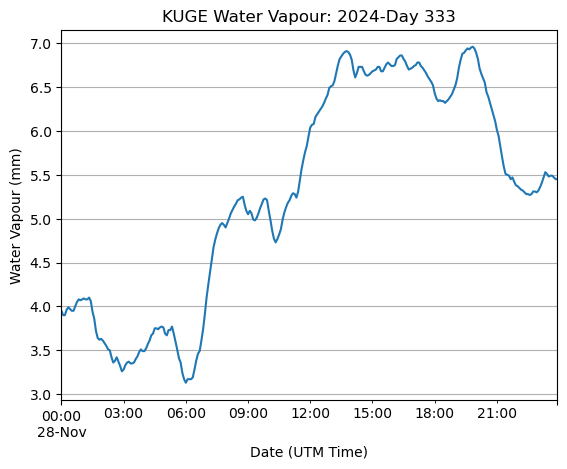

In [10]:
#make our first plot
kuge_2024_df['WVAPOR'].plot(title='KUGE Water Vapour: 2024-Day 333') 

plt.xlabel('Date (UTM Time)')
plt.ylabel('Water Vapour (mm)')
plt.grid()

In [11]:
# Convert time zone to Kathmandu time
local_timezone = 'Asia/Kathmandu'
kuge_2024_df['timestamp_UTC'] = kuge_2024_df.index
kuge_2024_df['timestamp_local'] = kuge_2024_df['timestamp_UTC'].dt.tz_convert(local_timezone) #
kuge_2024_df.set_index('timestamp_local', inplace=True)
kuge_2024_df.head()

,*SITE,___EPOCH____,WVAPOR,year,doy,timestamp_UTC
timestamp_local,,,,,,
2024-11-28 05:45:00+05:45,KUGE,24:333:00000,3.95,2024,333,2024-11-28 00:00:00+00:00
2024-11-28 05:50:00+05:45,KUGE,24:333:00300,3.90,2024,333,2024-11-28 00:05:00+00:00
2024-11-28 05:55:00+05:45,KUGE,24:333:00600,3.90,2024,333,2024-11-28 00:10:00+00:00
2024-11-28 06:00:00+05:45,KUGE,24:333:00900,3.96,2024,333,2024-11-28 00:15:00+00:00
2024-11-28 06:05:00+05:45,KUGE,24:333:01200,3.99,2024,333,2024-11-28 00:20:00+00:00


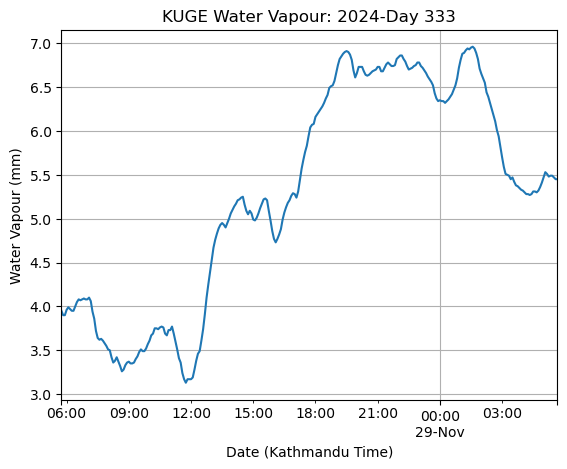

In [12]:
# Let's make a simple plot with Nepali Time
kuge_2024_df['WVAPOR'].plot(title='KUGE Water Vapour: 2024-Day 333') 

plt.xlabel('Date (Kathmandu Time)')
plt.ylabel('Water Vapour (mm)')
plt.grid()

# Load in all files from one directory

In [13]:
import glob

In [14]:
filelist=glob.glob('2024/KUGE*.gz')
filelist.sort()
filelist[0:10]

['2024/KUGE.2024.009.trop.gz',
 '2024/KUGE.2024.010.trop.gz',
 '2024/KUGE.2024.011.trop.gz',
 '2024/KUGE.2024.012.trop.gz',
 '2024/KUGE.2024.013.trop.gz',
 '2024/KUGE.2024.014.trop.gz',
 '2024/KUGE.2024.017.trop.gz',
 '2024/KUGE.2024.018.trop.gz',
 '2024/KUGE.2024.019.trop.gz',
 '2024/KUGE.2024.020.trop.gz']

In [15]:
# import all files and combine into one dataframe
all_files = []
for filename in filelist:
    df = pd.read_csv(filename, skiprows=54, delimiter=r'\s+', skipfooter=2, usecols=[0,1,9], engine='python')
    all_files.append(df)
kuge_2024_df = pd.concat(all_files)
kuge_2024_df.head()

,*SITE,___EPOCH____,WVAPOR
0,KUGE,24:009:17400,1.10
1,KUGE,24:009:17700,1.11
2,KUGE,24:009:18000,1.15
3,KUGE,24:009:18300,1.25
4,KUGE,24:009:18600,1.33


In [16]:
# now convert date data
split_cols = kuge_2024_df["___EPOCH____"].str.split(":", expand=True)
kuge_2024_df["year"] = 2000 + split_cols[0].astype(int)
kuge_2024_df["doy"] = split_cols[1].astype(int)
seconds = split_cols[2].astype(float)

# Build datetime
base_date = pd.to_datetime(kuge_2024_df["year"].astype(str), format="%Y")
kuge_2024_df["datetime"] = (
    base_date
    + pd.to_timedelta(kuge_2024_df["doy"] - 1, unit="D")
    + pd.to_timedelta(seconds, unit="s")
)

kuge_2024_df['datetime'] = kuge_2024_df['datetime'].dt.tz_localize('UTC')

# Convert time zone to Kathmandu time
local_timezone = 'Asia/Kathmandu'
kuge_2024_df['timestamp_local'] = kuge_2024_df['datetime'].dt.tz_convert(local_timezone) #
kuge_2024_df.set_index('timestamp_local', inplace=True)
kuge_2024_df.head()

kuge_2024_df.head()

,*SITE,___EPOCH____,WVAPOR,year,doy,datetime
timestamp_local,,,,,,
2024-01-09 10:35:00+05:45,KUGE,24:009:17400,1.10,2024,9,2024-01-09 04:50:00+00:00
2024-01-09 10:40:00+05:45,KUGE,24:009:17700,1.11,2024,9,2024-01-09 04:55:00+00:00
2024-01-09 10:45:00+05:45,KUGE,24:009:18000,1.15,2024,9,2024-01-09 05:00:00+00:00
2024-01-09 10:50:00+05:45,KUGE,24:009:18300,1.25,2024,9,2024-01-09 05:05:00+00:00
2024-01-09 10:55:00+05:45,KUGE,24:009:18600,1.33,2024,9,2024-01-09 05:10:00+00:00


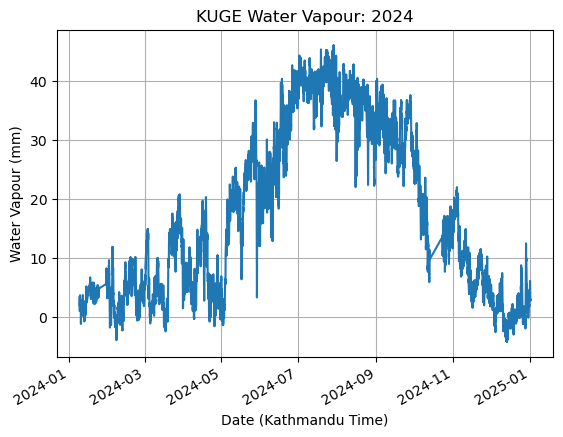

In [17]:
# Let's make a simple plot with Nepali Time
kuge_2024_df['WVAPOR'].plot(title='KUGE Water Vapour: 2024') 

plt.xlabel('Date (Kathmandu Time)')
plt.ylabel('Water Vapour (mm)')
plt.grid()

# Save Data

We can use pandas to save to a csv file. Per convention, we only save UTC time.

In [18]:
kuge_2024_df.to_csv('KUGE_2024_IWV.csv', columns=['datetime', 'WVAPOR'], index=False)

In [19]:
ls -larth *.csv

-rw-r--r-- 1 bodo bodo 3.0M Feb 21 11:11 KUGE_2024_IWV.csv


In [20]:
!head KUGE_2024_IWV.csv

datetime,WVAPOR
2024-01-09 04:50:00+00:00,1.1
2024-01-09 04:55:00+00:00,1.11
2024-01-09 05:00:00+00:00,1.15
2024-01-09 05:05:00+00:00,1.25
2024-01-09 05:10:00+00:00,1.33
2024-01-09 05:15:00+00:00,1.45
2024-01-09 05:20:00+00:00,1.57
2024-01-09 05:25:00+00:00,1.64
2024-01-09 05:30:00+00:00,1.7


# Next Steps
Import files from the years 2025 and 2026

In [21]:
filelist=glob.glob('2024/KUGE*.gz') + glob.glob('2025/KUGE*.gz') + glob.glob('2026/KUGE*.gz')
filelist.sort()
print(filelist[0:10])
print()
print(filelist[-10:])

['2024/KUGE.2024.009.trop.gz', '2024/KUGE.2024.010.trop.gz', '2024/KUGE.2024.011.trop.gz', '2024/KUGE.2024.012.trop.gz', '2024/KUGE.2024.013.trop.gz', '2024/KUGE.2024.014.trop.gz', '2024/KUGE.2024.017.trop.gz', '2024/KUGE.2024.018.trop.gz', '2024/KUGE.2024.019.trop.gz', '2024/KUGE.2024.020.trop.gz']

['2026/KUGE.2026.029.trop.gz', '2026/KUGE.2026.030.trop.gz', '2026/KUGE.2026.031.trop.gz', '2026/KUGE.2026.032.trop.gz', '2026/KUGE.2026.033.trop.gz', '2026/KUGE.2026.034.trop.gz', '2026/KUGE.2026.035.trop.gz', '2026/KUGE.2026.036.trop.gz', '2026/KUGE.2026.037.trop.gz', '2026/KUGE.2026.038.trop.gz']


In [22]:
# import all files and combine into one dataframe
all_files = []
for filename in filelist:
    df = pd.read_csv(filename, skiprows=54, delimiter=r'\s+', skipfooter=2, usecols=[0,1,9], engine='python')
    all_files.append(df)
kuge_2024_2025_2026_df = pd.concat(all_files)

# now convert date data
split_cols = kuge_2024_2025_2026_df["___EPOCH____"].str.split(":", expand=True)
kuge_2024_2025_2026_df["year"] = 2000 + split_cols[0].astype(int)
kuge_2024_2025_2026_df["doy"] = split_cols[1].astype(int)
seconds = split_cols[2].astype(float)

# Build datetime
base_date = pd.to_datetime(kuge_2024_2025_2026_df["year"].astype(str), format="%Y")
kuge_2024_2025_2026_df["datetime"] = (
    base_date
    + pd.to_timedelta(kuge_2024_2025_2026_df["doy"] - 1, unit="D")
    + pd.to_timedelta(seconds, unit="s")
)

kuge_2024_2025_2026_df['datetime'] = kuge_2024_2025_2026_df['datetime'].values.astype('datetime64[s]')
kuge_2024_2025_2026_df['datetime'] = kuge_2024_2025_2026_df['datetime'].dt.tz_localize('UTC')

# Convert time zone to Kathmandu time
local_timezone = 'Asia/Kathmandu'
kuge_2024_2025_2026_df['timestamp_local'] = kuge_2024_2025_2026_df['datetime'].dt.tz_convert(local_timezone) #
kuge_2024_2025_2026_df['timestamp_local'] = kuge_2024_2025_2026_df['timestamp_local'].values.astype('datetime64[s]')
kuge_2024_2025_2026_df.set_index('timestamp_local', inplace=True)
kuge_2024_2025_2026_df.head()


,*SITE,___EPOCH____,WVAPOR,year,doy,datetime
timestamp_local,,,,,,
2024-01-09 04:50:00,KUGE,24:009:17400,1.10,2024,9,2024-01-09 04:50:00+00:00
2024-01-09 04:55:00,KUGE,24:009:17700,1.11,2024,9,2024-01-09 04:55:00+00:00
2024-01-09 05:00:00,KUGE,24:009:18000,1.15,2024,9,2024-01-09 05:00:00+00:00
2024-01-09 05:05:00,KUGE,24:009:18300,1.25,2024,9,2024-01-09 05:05:00+00:00
2024-01-09 05:10:00,KUGE,24:009:18600,1.33,2024,9,2024-01-09 05:10:00+00:00


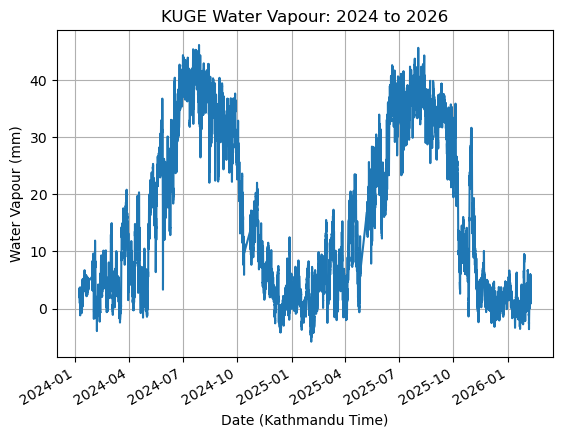

In [23]:
# Let's make a simple plot with Nepali Time
kuge_2024_2025_2026_df['WVAPOR'].plot(title='KUGE Water Vapour: 2024 to 2026') 

plt.xlabel('Date (Kathmandu Time)')
plt.ylabel('Water Vapour (mm)')
plt.grid()

## save to compressed csv

In [24]:
kuge_2024_2025_2026_df.to_csv('KUGE_2024_2025_2026_IWV.csv.gz', columns=['datetime', 'WVAPOR'], index=False)

In [25]:
!zcat KUGE_2024_2025_2026_IWV.csv.gz | head -10 

datetime,WVAPOR
2024-01-09 04:50:00+00:00,1.1
2024-01-09 04:55:00+00:00,1.11
2024-01-09 05:00:00+00:00,1.15
2024-01-09 05:05:00+00:00,1.25
2024-01-09 05:10:00+00:00,1.33
2024-01-09 05:15:00+00:00,1.45
2024-01-09 05:20:00+00:00,1.57
2024-01-09 05:25:00+00:00,1.64
2024-01-09 05:30:00+00:00,1.7

gzip: stdout: Broken pipe
